# Prediksi Loan Status menggunakan SVR

Notebook ini melakukan prediksi **Loan_Status** menggunakan algoritma **SVR (Support Vector Regression)** dengan threshold 0.5 untuk klasifikasi biner.

Dataset yang digunakan berasal dari 4 jenis transformasi:
- **Z-Score** (df_zscore, df_zscore_drop, df_zscore_replace)
- **Log Transform** (df_log, df_log_drop, df_log_replace)
- **MinMax Scaling** (df_minmax, df_minmax_drop, df_minmax_replace)
- **Decimal Scaling** (df_decimal, df_decimal_drop, df_decimal_replace)

Setiap dataset dievaluasi menggunakan **F1 Score, Precision, dan Recall**.

## 1. Import Library

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report
)

print('Libraries imported successfully!')

Libraries imported successfully!


In [39]:
import preprocessing2
print(preprocessing2.__file__)  # liat dia load dari mana

/media/pratama/Data/Other/SELURUH FILE PERKULIAHAN/MATERI SMESTER 6/Data Mining/Projek/projek1/syntax/preprocessing2.py


In [40]:
import traceback
try:
    import importlib
    import preprocessing2
    importlib.reload(preprocessing2)
except Exception as e:
    traceback.print_exc()

## 2. Import Dataset dari preprocessing2

In [41]:
from preprocessing2 import (
    df_ti_zscore, df_ti_log, df_ti_minmax, df_ti_decimal,
    df_lair_zscore, df_lair_log, df_lair_minmax, df_lair_decimal,
    df_both_zscore, df_both_log, df_both_minmax, df_both_decimal,
    df_ti_zscore_drop, df_ti_log_drop, df_ti_minmax_drop, df_ti_decimal_drop,
    df_lair_zscore_drop, df_lair_log_drop, df_lair_minmax_drop, df_lair_decimal_drop,
    df_both_zscore_drop, df_both_log_drop, df_both_minmax_drop, df_both_decimal_drop,
    df_ti_zscore_replace, df_ti_log_replace, df_ti_minmax_replace, df_ti_decimal_replace,
    df_lair_zscore_replace, df_lair_log_replace, df_lair_minmax_replace, df_lair_decimal_replace,
    df_both_zscore_replace, df_both_log_replace, df_both_minmax_replace, df_both_decimal_replace
)
print('Semua 36 dataset berhasil diimport!')


Semua 36 dataset berhasil diimport!


## 3. Definisi Fungsi SVR + Evaluasi

Fungsi berikut:
1. Memisahkan fitur (X) dan target (y = Loan_Status)
2. Drop kolom non-numerik (Loan_ID)
3. Split train/test 80/20
4. Training SVR dengan kernel RBF
5. Prediksi → threshold 0.5 → konversi ke label 0/1
6. Mengembalikan semua metrik evaluasi

In [42]:
def run_svr(df, dataset_name, test_size=0.2, random_state=42):
    """
    Melatih SVR pada dataset dan mengembalikan hasil evaluasi.

    Parameters:
        df           : DataFrame yang sudah di-encode dan di-transform
        dataset_name : Nama dataset (untuk label di output)
        test_size    : Proporsi data test (default 0.2 = 20%)
        random_state : Random seed

    Returns:
        dict berisi semua metrik evaluasi
    """
    df_clean = df.copy()

    # Drop kolom non-numerik (Loan_ID)
    if 'Loan_ID' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Loan_ID'])

    # Pisah fitur dan target
    X = df_clean.drop(columns=['Loan_Status'])
    y = df_clean['Loan_Status']

    # Split 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Training SVR
    svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
    svr.fit(X_train, y_train)

    # Prediksi → threshold 0.5
    y_pred_raw  = svr.predict(X_test)
    y_pred      = (y_pred_raw >= 0.5).astype(int)

    # Metrik
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    cm        = confusion_matrix(y_test, y_pred)

    return {
        'Dataset'   : dataset_name,
        'Accuracy'  : round(acc, 4),
        'Precision' : round(precision, 4),
        'Recall'    : round(recall, 4),
        'F1 Score'  : round(f1, 4),
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'cm'        : cm,
        'model'     : svr,
        'X_train'   : X_train,
        'X_test'    : X_test,
        'columns'   : X.columns.tolist(),
    }

print('Fungsi SVR siap digunakan!')

Fungsi SVR siap digunakan!


## 4. Training & Evaluasi Semua Dataset

Menjalankan SVR pada seluruh 12 dataset transformasi.

In [43]:
datasets = {
    'TI ZScore (Original)': df_ti_zscore,
    'TI Log (Original)': df_ti_log,
    'TI MinMax (Original)': df_ti_minmax,
    'TI Decimal (Original)': df_ti_decimal,
    'LAIR ZScore (Original)': df_lair_zscore,
    'LAIR Log (Original)': df_lair_log,
    'LAIR MinMax (Original)': df_lair_minmax,
    'LAIR Decimal (Original)': df_lair_decimal,
    'BOTH ZScore (Original)': df_both_zscore,
    'BOTH Log (Original)': df_both_log,
    'BOTH MinMax (Original)': df_both_minmax,
    'BOTH Decimal (Original)': df_both_decimal,
    'TI ZScore (Drop)': df_ti_zscore_drop,
    'TI Log (Drop)': df_ti_log_drop,
    'TI MinMax (Drop)': df_ti_minmax_drop,
    'TI Decimal (Drop)': df_ti_decimal_drop,
    'LAIR ZScore (Drop)': df_lair_zscore_drop,
    'LAIR Log (Drop)': df_lair_log_drop,
    'LAIR MinMax (Drop)': df_lair_minmax_drop,
    'LAIR Decimal (Drop)': df_lair_decimal_drop,
    'BOTH ZScore (Drop)': df_both_zscore_drop,
    'BOTH Log (Drop)': df_both_log_drop,
    'BOTH MinMax (Drop)': df_both_minmax_drop,
    'BOTH Decimal (Drop)': df_both_decimal_drop,
    'TI ZScore (Replace)': df_ti_zscore_replace,
    'TI Log (Replace)': df_ti_log_replace,
    'TI MinMax (Replace)': df_ti_minmax_replace,
    'TI Decimal (Replace)': df_ti_decimal_replace,
    'LAIR ZScore (Replace)': df_lair_zscore_replace,
    'LAIR Log (Replace)': df_lair_log_replace,
    'LAIR MinMax (Replace)': df_lair_minmax_replace,
    'LAIR Decimal (Replace)': df_lair_decimal_replace,
    'BOTH ZScore (Replace)': df_both_zscore_replace,
    'BOTH Log (Replace)': df_both_log_replace,
    'BOTH MinMax (Replace)': df_both_minmax_replace,
    'BOTH Decimal (Replace)': df_both_decimal_replace,
}

results = {}
for name, df_data in datasets.items():
    print(f'Training SVR: {name} ...')
    results[name] = run_svr(df_data, name)

print('\nSemua model selesai ditraining!')


Training SVR: TI ZScore (Original) ...
Training SVR: TI Log (Original) ...
Training SVR: TI MinMax (Original) ...
Training SVR: TI Decimal (Original) ...
Training SVR: LAIR ZScore (Original) ...
Training SVR: LAIR Log (Original) ...
Training SVR: LAIR MinMax (Original) ...
Training SVR: LAIR Decimal (Original) ...
Training SVR: BOTH ZScore (Original) ...
Training SVR: BOTH Log (Original) ...
Training SVR: BOTH MinMax (Original) ...
Training SVR: BOTH Decimal (Original) ...
Training SVR: TI ZScore (Drop) ...
Training SVR: TI Log (Drop) ...
Training SVR: TI MinMax (Drop) ...
Training SVR: TI Decimal (Drop) ...
Training SVR: LAIR ZScore (Drop) ...
Training SVR: LAIR Log (Drop) ...
Training SVR: LAIR MinMax (Drop) ...
Training SVR: LAIR Decimal (Drop) ...
Training SVR: BOTH ZScore (Drop) ...
Training SVR: BOTH Log (Drop) ...
Training SVR: BOTH MinMax (Drop) ...
Training SVR: BOTH Decimal (Drop) ...
Training SVR: TI ZScore (Replace) ...
Training SVR: TI Log (Replace) ...
Training SVR: TI Mi

## 5. Tabel Perbandingan Hasil Evaluasi

Rangkuman **Accuracy, Precision, Recall, dan F1 Score** dari semua 12 dataset.

In [44]:
summary = pd.DataFrame([
    {
        'Dataset'   : r['Dataset'],
        'Accuracy'  : r['Accuracy'],
        'Precision' : r['Precision'],
        'Recall'    : r['Recall'],
        'F1 Score'  : r['F1 Score'],
    }
    for r in results.values()
])

summary = summary.sort_values('F1 Score', ascending=False).reset_index(drop=True)

# Highlight nilai terbaik
summary.style.highlight_max(
    subset=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    color='lightgreen'
).highlight_min(
    subset=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    color='#ffcccc'
)

,Dataset,Accuracy,Precision,Recall,F1 Score
0,TI Decimal (Drop),0.862700,0.841500,0.985700,0.907900
1,TI MinMax (Drop),0.862700,0.841500,0.985700,0.907900
2,LAIR MinMax (Drop),0.862700,0.841500,0.985700,0.907900
3,LAIR Decimal (Drop),0.862700,0.841500,0.985700,0.907900
4,BOTH MinMax (Drop),0.862700,0.841500,0.985700,0.907900
5,BOTH Decimal (Drop),0.862700,0.841500,0.985700,0.907900
6,TI ZScore (Drop),0.862700,0.850000,0.971400,0.906700
7,LAIR ZScore (Drop),0.862700,0.850000,0.971400,0.906700
8,BOTH ZScore (Drop),0.862700,0.850000,0.971400,0.906700
9,LAIR Decimal (Replace),0.853700,0.831700,0.988200,0.903200


## 6. Visualisasi Perbandingan Metrik

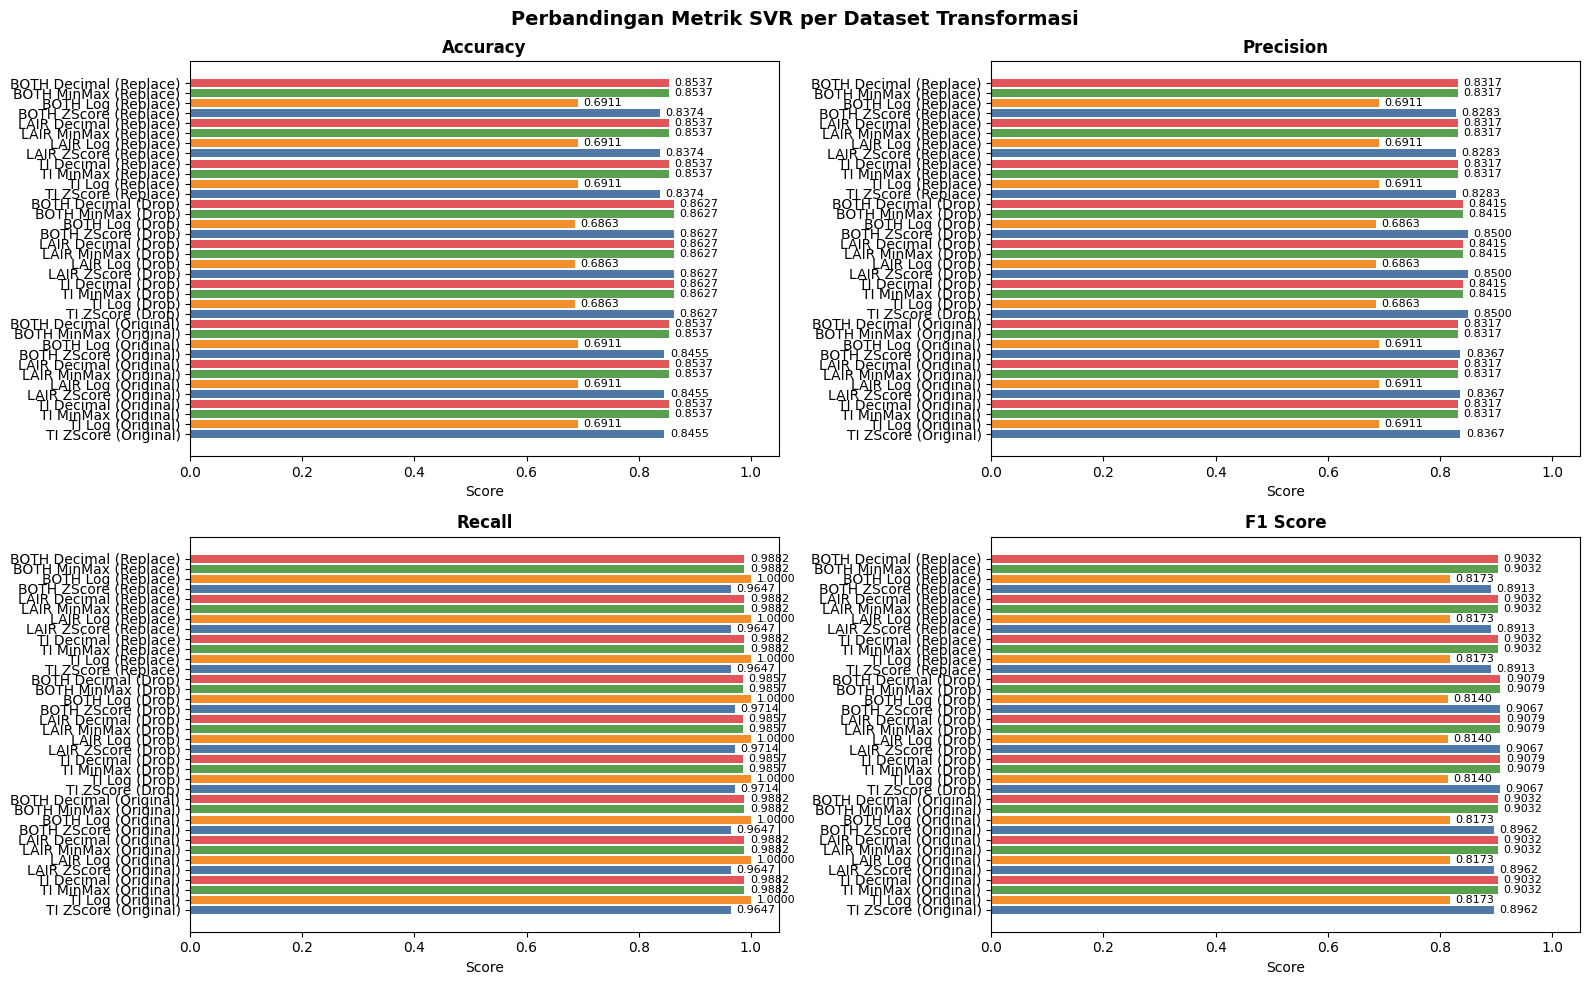

In [45]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Perbandingan Metrik SVR per Dataset Transformasi', fontsize=14, fontweight='bold')

colors = []
for name in datasets.keys():
    if 'ZScore' in name: colors.append('#4e79a7')
    elif 'Log' in name: colors.append('#f28e2b')
    elif 'MinMax' in name: colors.append('#59a14f')
    else: colors.append('#e15759')

for ax, metric in zip(axes.flatten(), metrics):
    vals = [results[name][metric] for name in datasets.keys()]
    bars = ax.barh(list(datasets.keys()), vals, color=colors)
    ax.set_xlim(0, 1.05)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Score')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 7. Confusion Matrix Semua Dataset

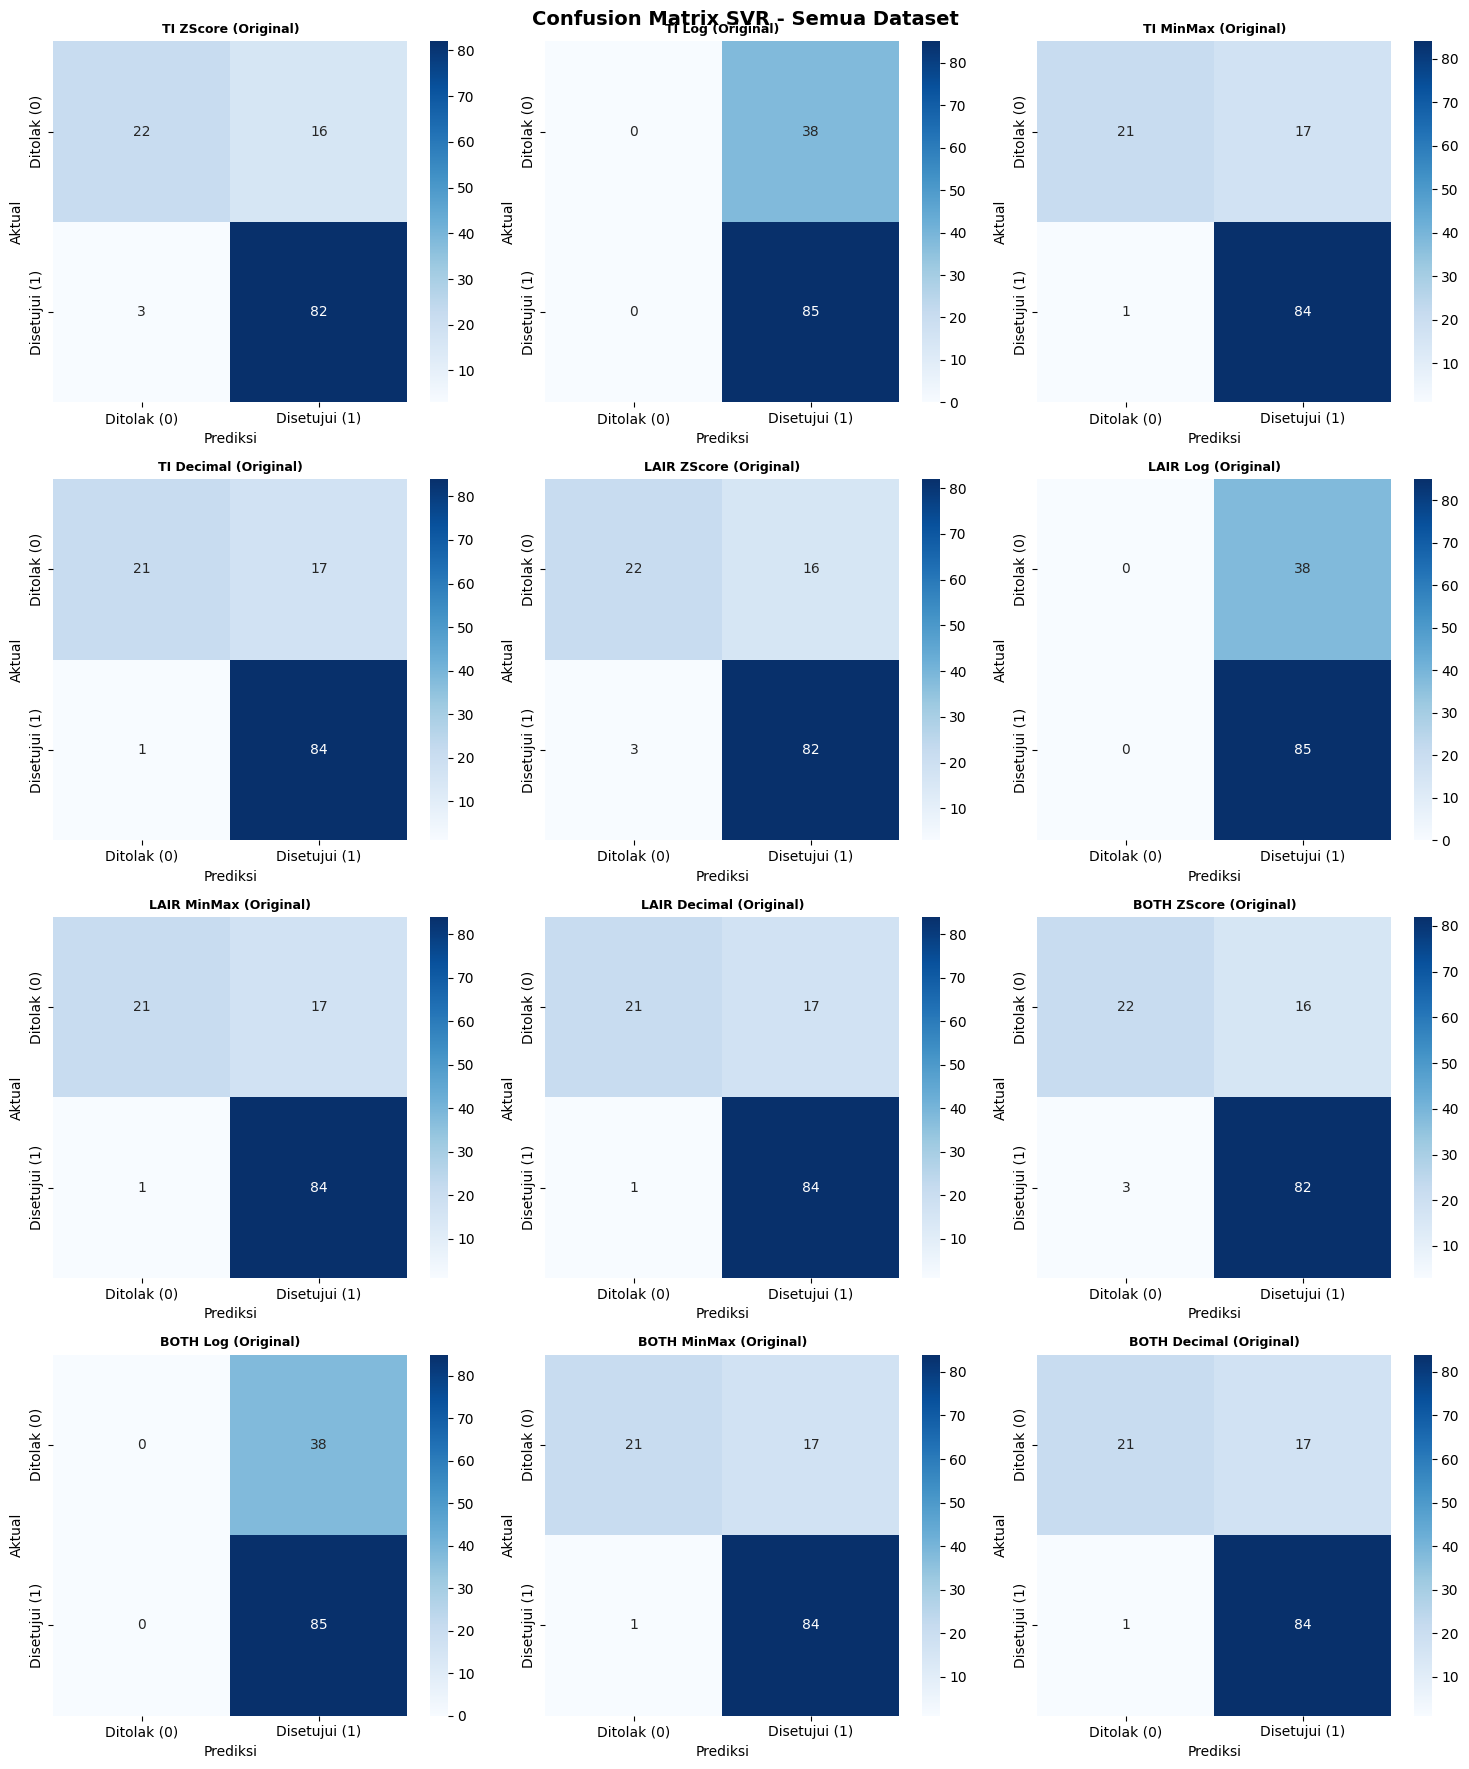

In [46]:
fig, axes = plt.subplots(4, 3, figsize=(15, 18))
fig.suptitle('Confusion Matrix SVR - Semua Dataset', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.flatten(), results.items()):
    sns.heatmap(
        res['cm'], annot=True, fmt='d', cmap='Blues',
        xticklabels=['Ditolak (0)', 'Disetujui (1)'],
        yticklabels=['Ditolak (0)', 'Disetujui (1)'],
        ax=ax
    )
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_ylabel('Aktual')
    ax.set_xlabel('Prediksi')

plt.tight_layout()
plt.show()

## 8. Classification Report Detail per Dataset

In [47]:
for name, res in results.items():
    print(f'{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(classification_report(
        res['y_test'], res['y_pred'],
        target_names=['Ditolak (0)', 'Disetujui (1)'],
        zero_division=0
    ))
    print()

  TI ZScore (Original)
               precision    recall  f1-score   support

  Ditolak (0)       0.88      0.58      0.70        38
Disetujui (1)       0.84      0.96      0.90        85

     accuracy                           0.85       123
    macro avg       0.86      0.77      0.80       123
 weighted avg       0.85      0.85      0.84       123


  TI Log (Original)
               precision    recall  f1-score   support

  Ditolak (0)       0.00      0.00      0.00        38
Disetujui (1)       0.69      1.00      0.82        85

     accuracy                           0.69       123
    macro avg       0.35      0.50      0.41       123
 weighted avg       0.48      0.69      0.56       123


  TI MinMax (Original)
               precision    recall  f1-score   support

  Ditolak (0)       0.95      0.55      0.70        38
Disetujui (1)       0.83      0.99      0.90        85

     accuracy                           0.85       123
    macro avg       0.89      0.77      0.80

## 9. Pengujian dengan Data Baru

Pengujian dilakukan pada **setiap model** (12 model) menggunakan satu sampel data baru.

> **Catatan:** Nilai data baru di bawah sudah dalam bentuk yang sesuai dengan transformasi masing-masing. Sesuaikan nilai input jika kamu ingin mencoba data lain.

In [48]:
# ── Data baru (raw, belum ditransformasi) ──────────────────────────
# Sesuaikan isi ini dengan data baru yang ingin diprediksi
new_data_raw = {
    'Gender'            : 1,      # 1=Male, 0=Female
    'Married'           : 1,      # 1=Yes, 0=No
    'Dependents'        : 3,    # 0, 1, 2, 3
    'Education'         : 0,      # 1=Graduate, 0=Not Graduate
    'Self_Employed'     : 0,      # 1=Yes, 0=No
    'ApplicantIncome'   : 1000,
    'CoapplicantIncome' : 1000,
    'LoanAmount'        : 150,
    'Loan_Amount_Term'  : 360,
    'Credit_History'    : 0.0,
    'Property_Area'     : 2,      # 1=Urban, 2=Rural, 3=Semiurban
    'Total_Income'      : 2000,
    'Loan_Amount_Income_Ratio': (150/2000) + 1,
}

new_df = pd.DataFrame([new_data_raw])
print('Data baru yang akan diprediksi:')
print(new_df.T)

Data baru yang akan diprediksi:
                                 0
Gender                       1.000
Married                      1.000
Dependents                   3.000
Education                    0.000
Self_Employed                0.000
ApplicantIncome           1000.000
CoapplicantIncome         1000.000
LoanAmount                 150.000
Loan_Amount_Term           360.000
Credit_History               0.000
Property_Area                2.000
Total_Income              2000.000
Loan_Amount_Income_Ratio     1.075


In [49]:
print('\n' + '='*55)
print('  HASIL PREDIKSI DATA BARU - SEMUA MODEL')
print('='*55)

new_predictions = []

for name, res in results.items():
    model   = res['model']
    cols    = res['columns']

    # Pastikan kolom input sesuai urutan training
    input_data = new_df[cols] if all(c in new_df.columns for c in cols) else None

    if input_data is None:
        print(f'{name:30s} : Kolom tidak lengkap, skip')
        continue

    pred_raw = model.predict(input_data)[0]
    pred_label = 1 if pred_raw >= 0.5 else 0
    status = 'DISETUJUI ✅' if pred_label == 1 else 'DITOLAK ❌'

    print(f'{name:30s} : {status}  (raw={pred_raw:.4f})')
    new_predictions.append({
        'Dataset'    : name,
        'Raw Score'  : round(pred_raw, 4),
        'Prediksi'   : pred_label,
        'Status'     : 'Disetujui' if pred_label == 1 else 'Ditolak'
    })

print('='*55)
pred_df = pd.DataFrame(new_predictions)
print(f"\nRingkasan: {(pred_df['Prediksi']==1).sum()} model prediksi DISETUJUI, "
      f"{(pred_df['Prediksi']==0).sum()} model prediksi DITOLAK")


  HASIL PREDIKSI DATA BARU - SEMUA MODEL
TI ZScore (Original)           : DISETUJUI ✅  (raw=0.5694)
TI Log (Original)              : DISETUJUI ✅  (raw=0.8359)
TI MinMax (Original)           : DISETUJUI ✅  (raw=0.5387)
TI Decimal (Original)          : DISETUJUI ✅  (raw=0.6592)
LAIR ZScore (Original)         : DISETUJUI ✅  (raw=0.5694)
LAIR Log (Original)            : DISETUJUI ✅  (raw=0.8359)
LAIR MinMax (Original)         : DISETUJUI ✅  (raw=0.5387)
LAIR Decimal (Original)        : DISETUJUI ✅  (raw=0.6592)
BOTH ZScore (Original)         : DISETUJUI ✅  (raw=0.5694)
BOTH Log (Original)            : DISETUJUI ✅  (raw=0.8359)
BOTH MinMax (Original)         : DISETUJUI ✅  (raw=0.5387)
BOTH Decimal (Original)        : DISETUJUI ✅  (raw=0.6592)
TI ZScore (Drop)               : DITOLAK ❌  (raw=0.4982)
TI Log (Drop)                  : DISETUJUI ✅  (raw=0.8203)
TI MinMax (Drop)               : DISETUJUI ✅  (raw=0.5055)
TI Decimal (Drop)              : DISETUJUI ✅  (raw=0.6189)
LAIR ZScore (Dro

## 10. Ringkasan Akhir & Rekomendasi Model Terbaik

In [50]:
print('RANGKUMAN PERFORMA MODEL (diurutkan F1 Score)')
print('='*65)
print(summary.to_string(index=False))

best = summary.iloc[0]
worst = summary.iloc[-1]

print(f'\n🏆 Model TERBAIK  : {best["Dataset"]}')
print(f'   F1={best["F1 Score"]:.4f} | Precision={best["Precision"]:.4f} | Recall={best["Recall"]:.4f} | Accuracy={best["Accuracy"]:.4f}')

print(f'\n⚠️  Model TERENDAH : {worst["Dataset"]}')
print(f'   F1={worst["F1 Score"]:.4f} | Precision={worst["Precision"]:.4f} | Recall={worst["Recall"]:.4f} | Accuracy={worst["Accuracy"]:.4f}')

RANGKUMAN PERFORMA MODEL (diurutkan F1 Score)
                Dataset  Accuracy  Precision  Recall  F1 Score
      TI Decimal (Drop)    0.8627     0.8415  0.9857    0.9079
       TI MinMax (Drop)    0.8627     0.8415  0.9857    0.9079
     LAIR MinMax (Drop)    0.8627     0.8415  0.9857    0.9079
    LAIR Decimal (Drop)    0.8627     0.8415  0.9857    0.9079
     BOTH MinMax (Drop)    0.8627     0.8415  0.9857    0.9079
    BOTH Decimal (Drop)    0.8627     0.8415  0.9857    0.9079
       TI ZScore (Drop)    0.8627     0.8500  0.9714    0.9067
     LAIR ZScore (Drop)    0.8627     0.8500  0.9714    0.9067
     BOTH ZScore (Drop)    0.8627     0.8500  0.9714    0.9067
 LAIR Decimal (Replace)    0.8537     0.8317  0.9882    0.9032
   TI MinMax (Original)    0.8537     0.8317  0.9882    0.9032
  TI Decimal (Original)    0.8537     0.8317  0.9882    0.9032
 BOTH Decimal (Replace)    0.8537     0.8317  0.9882    0.9032
BOTH Decimal (Original)    0.8537     0.8317  0.9882    0.9032
  BOTH Mi